In [1]:
import pandas as pd
import scipy.stats
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.preprocessing import TargetEncoder
from concurrent.futures import ThreadPoolExecutor
import itertools
import gc
from lightgbm import LGBMClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
import warnings
warnings.filterwarnings("ignore")

This dataframe does not contain the first two weeks of data (to ensure stability in features).

In [2]:
df = pd.read_parquet("data/candidate_variables.parquet")
df.Date.min(), df.Date.max()

(Timestamp('2010-01-15 00:00:00'), Timestamp('2010-12-31 00:00:00'))

We leave the last two months of data for true out-of-sample validation.

In [3]:
df = df[df.Date < '2010-11-01']
df.drop(columns=['Recnum', 'Date', 'Cardnum', 'Merchnum', 'Amount',
            'Merch description', 'Merch state', 'Merch zip', 'DayOfWeek'], inplace=True)

In [4]:
df.shape

(81892, 6874)

## Procedure
This notebook follows a two-step procedure to select strong features. 
- Stage 1: Filters out weak candidate features by ranking the Kolmogorov-Smirnov statistic. (Select Top N)
- Stage 2: Uses Sequential Feature Selection to iteratively test for predictive performance. 

In [5]:
NUM_OUT_OF_FILTER = 1375  # Top variables to keep after KS filter (10-20% of total)
NUM_OUT_OF_WRAPPER = 20  # Final variables after wrapper selection
DETECT_RATE = 0.03       # Top 3% for Fraud Detection Rate calculation

print(f"{df.shape[0]} rows, {df.shape[1]-1} candidate features")

81892 rows, 6873 candidate features


### Stage 1: Kolmogorov-Smirnov Statistic

In [6]:
# random variable as control (should not be selected)
df['RANDOM'] = np.random.rand(len(df))

frauds = df[df['Fraud'] == 1]
non_frauds = df[df['Fraud'] == 0]

print(f"Class distribution: {len(frauds)} frauds, {len(non_frauds)} non-frauds")

Class distribution: 1975 frauds, 79917 non-frauds


In [7]:
ks_scores = []

for col in tqdm(df.columns):
    if col == 'Fraud':
        continue
    
    ks_stat = scipy.stats.ks_2samp(non_frauds[col], frauds[col])[0]
    ks_scores.append({'variable': col, 'filter_score': ks_stat})

filter_score = pd.DataFrame(ks_scores).sort_values('filter_score', ascending=False)

print(f"\nTop 20 features by KS score:")
print(filter_score.head(20))

100%|██████████| 6875/6875 [00:37<00:00, 185.67it/s]


Top 20 features by KS score:
                          variable  filter_score
14                 Cardnum_total_1      0.612331
23                 Cardnum_total_3      0.584312
407               card_dow_total_3      0.580315
5                  Cardnum_total_0      0.580315
389               card_dow_total_0      0.580315
398               card_dow_total_1      0.580315
12                   Cardnum_max_1      0.578072
10                 Cardnum_count_1      0.576926
19                 Cardnum_count_3      0.572196
405                 card_dow_max_3      0.561139
387                 card_dow_max_0      0.561139
3                    Cardnum_max_0      0.561139
396                 card_dow_max_1      0.561139
1679  Cardnum_total_amount_1_by_60      0.548868
2087         Cardnum_vdratio_1by60      0.548583
386                 card_dow_avg_0      0.544140
404                 card_dow_avg_3      0.544140
2                    Cardnum_avg_0      0.544140
395                 card_dow_avg_1     

In [8]:
# keep top N
vars_keep = filter_score['variable'].head(NUM_OUT_OF_FILTER).tolist()
print(f"Retaining {len(vars_keep)} features for wrapper selection")

X = df[vars_keep]
y = df['Fraud']

Retaining 1375 features for wrapper selection


### Fraud Detection Rate

In [9]:
# SFS expects this input format during cross-validation
def fdr_sfs_scorer(estimator, X, y):
    # we define DETECT_RATE above
    
    try:
        y_prob = estimator.predict_proba(X)
    except Exception as e:
        print(f"Prediction Error: {e}")
        return 0.0

    # - Shape Handling -
    # handle LightGBM's output (N, 2) or (N, 1)
    # since fraud is rare, possible for one fold to have only one class, outputting (N, 1)
    if hasattr(y_prob, 'ndim') and y_prob.ndim > 1:
        # If we have a 2nd column (positive class), use it. Otherwise use the first (only) column.
        target_col = 1 if y_prob.shape[1] > 1 else 0
        y_prob = y_prob[:, target_col]
    
    y_prob = np.asarray(y_prob).flatten()
    y_true = np.asarray(y)

    # - FDR Calculation -
    n_top = max(1, int(len(y_true) * DETECT_RATE))
    top_indices = np.argsort(y_prob)[-n_top:]   # argsort sorts low -> high, so we take the last n_top
    total_frauds = np.sum(y_true == 1)
    
    if total_frauds == 0:
        return 0.0
        
    frauds_caught = np.sum(y_true[top_indices] == 1)
    
    return float(frauds_caught / total_frauds)

### Stage 2: Sequential Feature Selection

In [10]:
# classifier (clf)
clf = LGBMClassifier(n_estimators=20, num_leaves=4, verbose=-1)

sfs = SFS(
    clf,
    k_features=NUM_OUT_OF_WRAPPER,
    forward=True,
    verbose=1,
    scoring=fdr_sfs_scorer,
    cv=2,
    n_jobs=-1
)

sfs.fit(X, y)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:   14.3s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:   17.8s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   26.4s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   37.2s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:   49.9s
[Parallel(n_jobs=-1)]: Done 1375 out of 1375 | elapsed:   53.5s finished
Features: 1/20[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 434 tasks      | elapsed:   13.8s
[Parallel(n_jobs=-1)]: Done 784 tasks      | elapsed:   25.0s
[Parallel(n_jobs=-1)]: Done 1234 tasks      | elapsed:   39.0s
[Parallel(n_jobs=-1)]: Done 1374 out of 1374 | elapsed:   43.0s finished
Features: 2/20[Parallel(n_jobs=-1)]: Using backend LokyBackend wit

,estimator,"LGBMClassifie...4, verbose=-1)"
,k_features,"(20, ...)"
,forward,True
,floating,False
,verbose,1
,scoring,<function fdr...002257F3F20E0>
,cv,2
,n_jobs,-1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


### Results & Visualization

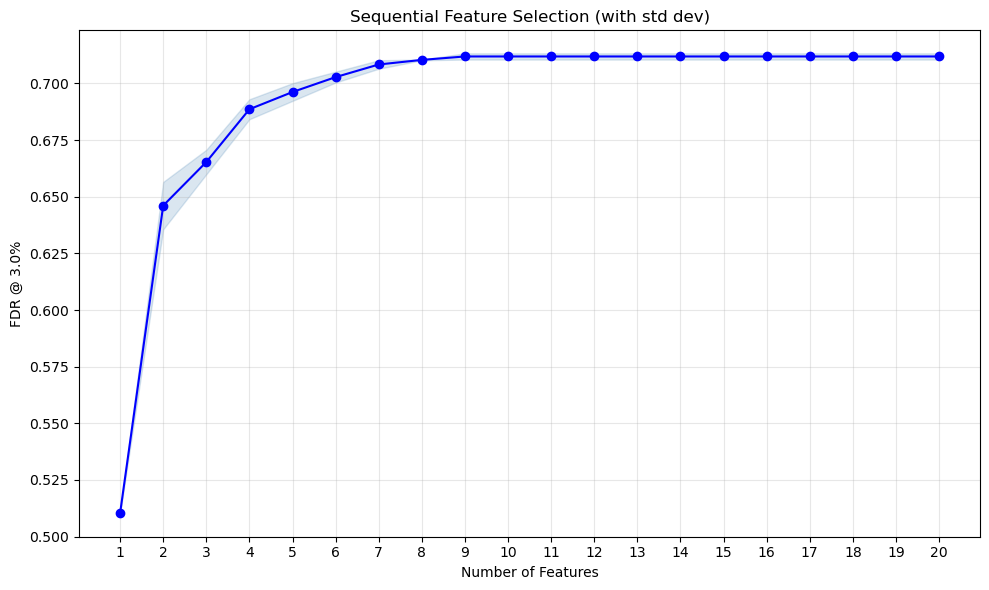

In [11]:
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs

fig1 = plot_sfs(sfs.get_metric_dict(), kind='std_dev', figsize=(10, 6))
plt.title('Sequential Feature Selection (with std dev)')
plt.xlabel('Number of Features')
plt.ylabel(f'FDR @ {DETECT_RATE*100}%')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [12]:
md = sfs.get_metric_dict()
order, prev = [], set()
for step in sorted(md, key=lambda x: int(x)):
    curr = set(md[step]['feature_names'])
    add = curr - prev
    if add:
        order.append(next(iter(add)))
    prev = curr

ks = dict(zip(filter_score['variable'], filter_score['filter_score']))
for i, feat in enumerate(order, 1):
    print(f"{i:2d}. {feat}: KS = {ks.get(feat, np.nan):.4f}")

 1. Cardnum_unique_count_for_card_state_1: KS = 0.5085
 2. card_merchdesc_state_total_14: KS = 0.1752
 3. card_dow_count_1_by_30: KS = 0.5161
 4. merchnum_desc_total_1: KS = 0.1706
 5. card_zip3_total_30: KS = 0.1784
 6. card_merchdesc_zip_max_60: KS = 0.1696
 7. card_dow_unique_count_for_Merchnum_1: KS = 0.4843
 8. card_merchdesc_zip_actual/med_60: KS = 0.1701
 9. card_merchnum_state_total_amount_1_by_60: KS = 0.1584
10. card_dow_count_0_by_30_sq: KS = 0.5161
11. card_dow_count_0_by_30: KS = 0.5161
12. card_dow_count_1_by_30_sq: KS = 0.5161
13. card_dow_vdratio_0by30: KS = 0.5161
14. card_dow_vdratio_1by30: KS = 0.5161
15. Cardnum_vdratio_1by7: KS = 0.4956
16. card_dow_unique_count_for_merch_state_1: KS = 0.4843
17. card_dow_unique_count_for_card_merchnum_state_3: KS = 0.4843
18. card_dow_unique_count_for_card_merch_3: KS = 0.4843
19. card_dow_unique_count_for_card_merch_1: KS = 0.4843
20. card_dow_unique_count_for_Merchnum_3: KS = 0.4843


In [13]:
df_ks = pd.DataFrame({
    'feature': order,
    'wrapper_order': range(1, len(order) + 1),
    'ks_stat': [ks.get(f, np.nan) for f in order]
})

In [14]:
out_path = 'data/selected_features_ks.csv'
df_ks.to_csv(out_path, index=False)